In [40]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras



In [41]:
from google.colab import files
uploaded = files.upload()

Saving deliverytime.txt to deliverytime (1).txt


In [42]:
df=pd.read_csv('deliverytime.txt')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [43]:
df.isna().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Type_of_order,0
Type_of_vehicle,0


In [44]:
dummies=pd.get_dummies(df[['Type_of_order', 'Type_of_vehicle']]
,dtype=int,drop_first=True)
dummies

,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,0,0,1,0,1,0
1,0,0,1,0,0,1
2,1,0,0,0,1,0
3,0,0,0,0,1,0
4,0,0,1,0,0,1
...,...,...,...,...,...,...
45588,0,1,0,0,1,0
45589,0,0,0,0,1,0
45590,1,0,0,0,0,1
45591,0,0,1,0,1,0


In [45]:
df1=pd.concat([df,dummies],axis='columns')
df1

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min),Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24,0,0,1,0,1,0
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33,0,0,1,0,0,1
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26,1,0,0,0,1,0
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21,0,0,0,0,1,0
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,7C09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,Meal,motorcycle,32,0,1,0,0,1,0
45589,D641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,Buffet,motorcycle,36,0,0,0,0,1,0
45590,4F8D,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,Drinks,scooter,16,1,0,0,0,0,1
45591,5EEE,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,Snack,motorcycle,26,0,0,1,0,1,0


In [46]:
df1.drop(['ID','Delivery_person_ID'],axis='columns',inplace=True)

now will calculate the distance of the destination using the values of latitude and longitude

In [47]:

# Haversine formula implementation
def haversine_distance(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Radius of Earth in kilometers. Use 3956 for miles
    r = 6371
    return c * r

# Assuming you have a DataFrame called df
# df = pd.read_csv("your_file.csv")

# Add a new column 'Distance_km' to the DataFrame
df1["Distance_km"] = haversine_distance(
    df1["Restaurant_latitude"],
    df1["Restaurant_longitude"],
    df1["Delivery_location_latitude"],
    df1["Delivery_location_longitude"]
)
df1

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min),Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Distance_km
0,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24,0,0,1,0,1,0,3.025149
1,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33,0,0,1,0,0,1,20.183530
2,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26,1,0,0,0,1,0,1.552758
3,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21,0,0,0,0,1,0,7.790401
4,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30,0,0,1,0,0,1,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,30,4.8,26.902328,75.794257,26.912328,75.804257,Meal,motorcycle,32,0,1,0,0,1,0,1.489846
45589,21,4.6,0.000000,0.000000,0.070000,0.070000,Buffet,motorcycle,36,0,0,0,0,1,0,11.007735
45590,30,4.9,13.022394,80.242439,13.052394,80.272439,Drinks,scooter,16,1,0,0,0,0,1,4.657195
45591,20,4.7,11.001753,76.986241,11.041753,77.026241,Snack,motorcycle,26,0,0,1,0,1,0,6.232393


In [48]:
df1.drop(['Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude'],axis='columns',inplace=True)
df1

,Delivery_person_Age,Delivery_person_Ratings,Type_of_order,Type_of_vehicle,Time_taken(min),Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Distance_km
0,37,4.9,Snack,motorcycle,24,0,0,1,0,1,0,3.025149
1,34,4.5,Snack,scooter,33,0,0,1,0,0,1,20.183530
2,23,4.4,Drinks,motorcycle,26,1,0,0,0,1,0,1.552758
3,38,4.7,Buffet,motorcycle,21,0,0,0,0,1,0,7.790401
4,32,4.6,Snack,scooter,30,0,0,1,0,0,1,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...
45588,30,4.8,Meal,motorcycle,32,0,1,0,0,1,0,1.489846
45589,21,4.6,Buffet,motorcycle,36,0,0,0,0,1,0,11.007735
45590,30,4.9,Drinks,scooter,16,1,0,0,0,0,1,4.657195
45591,20,4.7,Snack,motorcycle,26,0,0,1,0,1,0,6.232393


In [49]:
df1

,Delivery_person_Age,Delivery_person_Ratings,Type_of_order,Type_of_vehicle,Time_taken(min),Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Distance_km
0,37,4.9,Snack,motorcycle,24,0,0,1,0,1,0,3.025149
1,34,4.5,Snack,scooter,33,0,0,1,0,0,1,20.183530
2,23,4.4,Drinks,motorcycle,26,1,0,0,0,1,0,1.552758
3,38,4.7,Buffet,motorcycle,21,0,0,0,0,1,0,7.790401
4,32,4.6,Snack,scooter,30,0,0,1,0,0,1,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...
45588,30,4.8,Meal,motorcycle,32,0,1,0,0,1,0,1.489846
45589,21,4.6,Buffet,motorcycle,36,0,0,0,0,1,0,11.007735
45590,30,4.9,Drinks,scooter,16,1,0,0,0,0,1,4.657195
45591,20,4.7,Snack,motorcycle,26,0,0,1,0,1,0,6.232393


In [50]:
df1.columns


Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Type_of_order',
       'Type_of_vehicle', 'Time_taken(min)', 'Type_of_order_Drinks ',
       'Type_of_order_Meal ', 'Type_of_order_Snack ',
       'Type_of_vehicle_electric_scooter ', 'Type_of_vehicle_motorcycle ',
       'Type_of_vehicle_scooter ', 'Distance_km'],
      dtype='object')

now will visualise the data

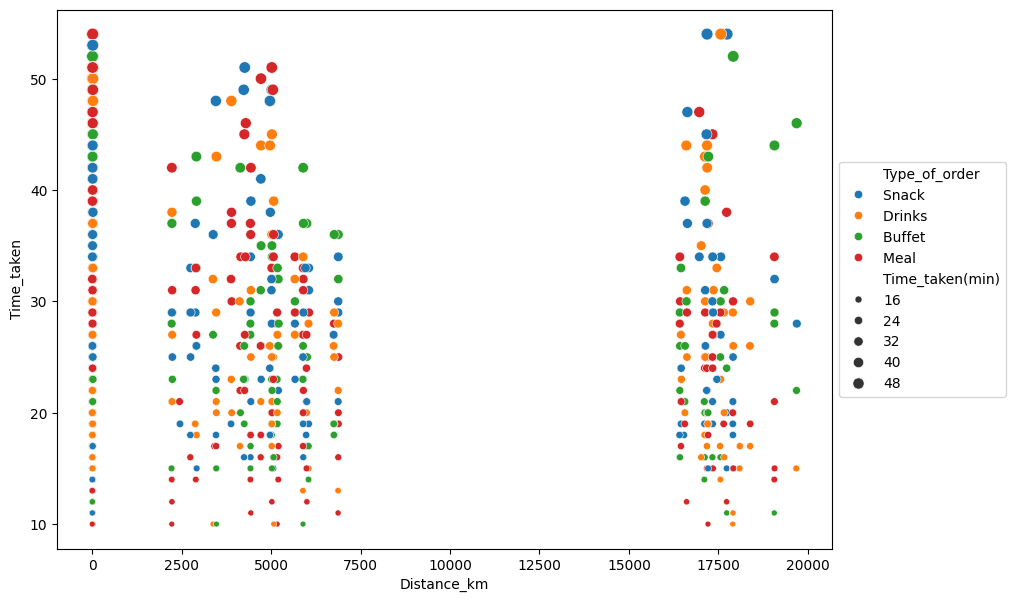

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 7))  # Adjust figure size as needed

# Create the scatter plot
sns.scatterplot(data=df1, x='Distance_km', y='Time_taken(min)', hue='Type_of_order', size='Time_taken(min)', ax=ax)

# Set labels
ax.set_xlabel('Distance_km')
ax.set_ylabel('Time_taken')

# Move the legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [64]:
from sklearn.feature_selection import mutual_info_classif
df1.drop(['Type_of_order','Type_of_vehicle'],axis='columns',inplace=True)
x=df1.drop('Time_taken(min)',axis=1)
y=df1['Time_taken(min)']
mi=mutual_info_classif(x,y)
mi=pd.Series(mi)
mi.index=x.columns
mi.sort_values(ascending=False)


,0
Delivery_person_Ratings,0.156491
Distance_km,0.092457
Delivery_person_Age,0.069967
Type_of_vehicle_motorcycle,0.024303
Type_of_vehicle_scooter,0.014613
Type_of_order_Drinks,0.006121
Type_of_order_Meal,0.000000
Type_of_order_Snack,0.000000
Type_of_vehicle_electric_scooter,0.000000


In [67]:
x1=df1[['Delivery_person_Age','Delivery_person_Ratings','Distance_km']]
y1=df1[['Time_taken(min)']]

In [75]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x1,y1,test_size=0.2,random_state=5)
x_train.shape


(36474, 3)

In [85]:
from tensorflow.keras import models,layers,callbacks

model = models.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [86]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history=model.fit(x_train,y_train,epochs=50,batch_size=32,  validation_split=0.2,callbacks=[early_stop])


Epoch 1/50
912/912 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 677.2330 - mae: 9.9880 - val_loss: 75.6256 - val_mae: 6.9488
Epoch 2/50
912/912 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 85.7619 - mae: 7.0224 - val_loss: 75.0258 - val_mae: 6.9831
Epoch 3/50
912/912 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 82.6003 - mae: 6.9533 - val_loss: 89.2857 - val_mae: 7.0769
Epoch 4/50
912/912 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 181.7278 - mae: 7.3075 - val_loss: 73.3648 - val_mae: 6.8923
Epoch 5/50
912/912 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 74.7798 - mae: 6.8023 - val_loss: 82.5577 - val_mae: 7.0974
Epoch 6/50
912/912 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 73.0180 - mae: 6.7716 - val_loss: 75.5717 - val_mae: 6.9211
Epoch 7/50
912/912 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 74.1604 - mae: 6.8101 - val_loss: 78.2035 - val_mae: 7.0417
Epoch 8/50
912/912 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 74.2786 - mae: 6.8343 - val_loss: 73.3646 - val_mae: 6.8453
Epoch 9/50
912/912 ━━━━━━━━━━━━━━━━━━━

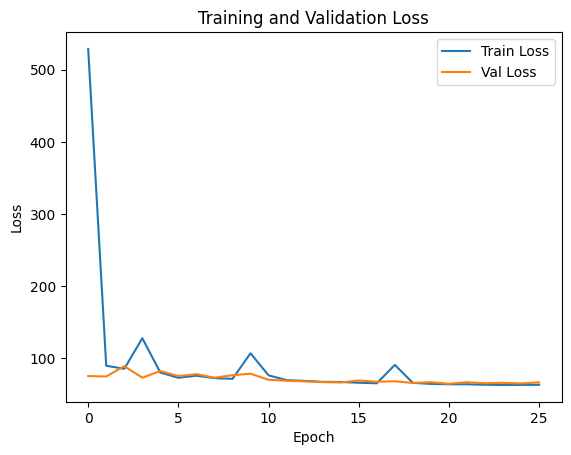

In [87]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history.get('val_loss', []), label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [89]:
import numpy as np

print("🚚 Food Delivery Time Prediction")
try:
    a = int(input("Age of Delivery Partner: "))
    b = float(input("Ratings of Delivery Partner (e.g., 4.5): "))
    c = float(input("Distance to Customer (in km): "))

    # Model expects 2D input: (1, 3)
    features = np.array([[a, b, c]])

    predicted_time = model.predict(features)
    print(f"\n⏱️ Predicted Delivery Time: {predicted_time[0][0]:.2f} minutes")

except ValueError:
    print("❌ Please enter valid numeric values.")


🚚 Food Delivery Time Prediction
Age of Delivery Partner: 27
Ratings of Delivery Partner (e.g., 4.5): 4.3
Distance to Customer (in km): 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

⏱️ Predicted Delivery Time: 28.07 minutes
